In [86]:
# Загрузка датасетов

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logs = pd.read_csv('logs.csv')
user_data = pd.read_csv('user_data.csv')

In [87]:
logs.head(3)

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894


In [88]:
user_data.head(3)

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64


Проверим размеры таблиц

In [89]:
logs.shape

(4500, 4)

In [90]:
user_data.shape

(2954, 3)

Посмотрим на типы переменных в каждом датасете

In [91]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   client    4500 non-null   int64 
 1   success   4500 non-null   bool  
 2   platform  4500 non-null   object
 3   time      4500 non-null   int64 
dtypes: bool(1), int64(2), object(1)
memory usage: 110.0+ KB


In [92]:
user_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2954 entries, 0 to 2953
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   client   2954 non-null   int64
 1   premium  2954 non-null   bool 
 2   age      2954 non-null   int64
dtypes: bool(1), int64(2)
memory usage: 49.2 KB


Посмотрим на описательную статистику каждого датасета

In [93]:
logs.describe()

,client,time
count,4500.000000,4.500000e+03
mean,50998.758000,1.585440e+09
std,28374.472495,2.314866e+04
min,40.000000,1.585400e+09
25%,27056.500000,1.585420e+09
50%,52659.000000,1.585440e+09
75%,76001.250000,1.585461e+09
max,99993.000000,1.585480e+09


In [94]:
# Посмотрим сколько уникальных значений принимает platform

logs.platform.unique()

array(['phone', 'computer', 'tablet'], dtype=object)

In [95]:
# Узнаем какой клиент совершил больше всего успешных операций

counts_operations = (
    logs.query('success == 1')
    .groupby('client', as_index=False)
    .agg(count_operation=('platform', 'count'))
    .sort_values('count_operation', ascending=False)
)

max_value = counts_operations['count_operation'].max()
','.join(counts_operations[counts_operations['count_operation'] == max_value]['client'].astype(str).sort_values())

'12179,28719,36165,52870,61468,61473,78349,82563,92584'

In [96]:
# Узнаем с какой платвформы осуществлялось наибольшее количество успешных операций

(
    logs.query('success == 1')
    .groupby('platform', as_index=False)
    .agg(count_operation=('client', 'count'))
    .sort_values('count_operation', ascending=False)
    .head(1)
)

,platform,count_operation
1,phone,2019


In [97]:
# Узнаем какая платформа наиболее популярна у премиумных клиентов
# Для этого сначала объединим две таблицы

df = logs.merge(user_data, on='client')
(
    df.query('premium == True')
    .groupby('platform', as_index=False)
    .agg(count=('age', 'count'))
    .sort_values('count', ascending=False)
    .head(1)
)

,platform,count
1,phone,246


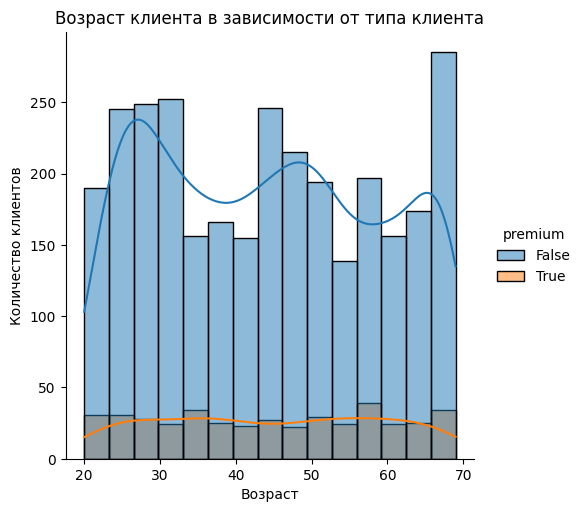

In [98]:
# Построим распределение возраста клиента в зависимости от типа клиента

sns.displot(df, x='age', hue='premium', kde=True)
plt.title('Возраст клиента в зависимости от типа клиента')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.show()

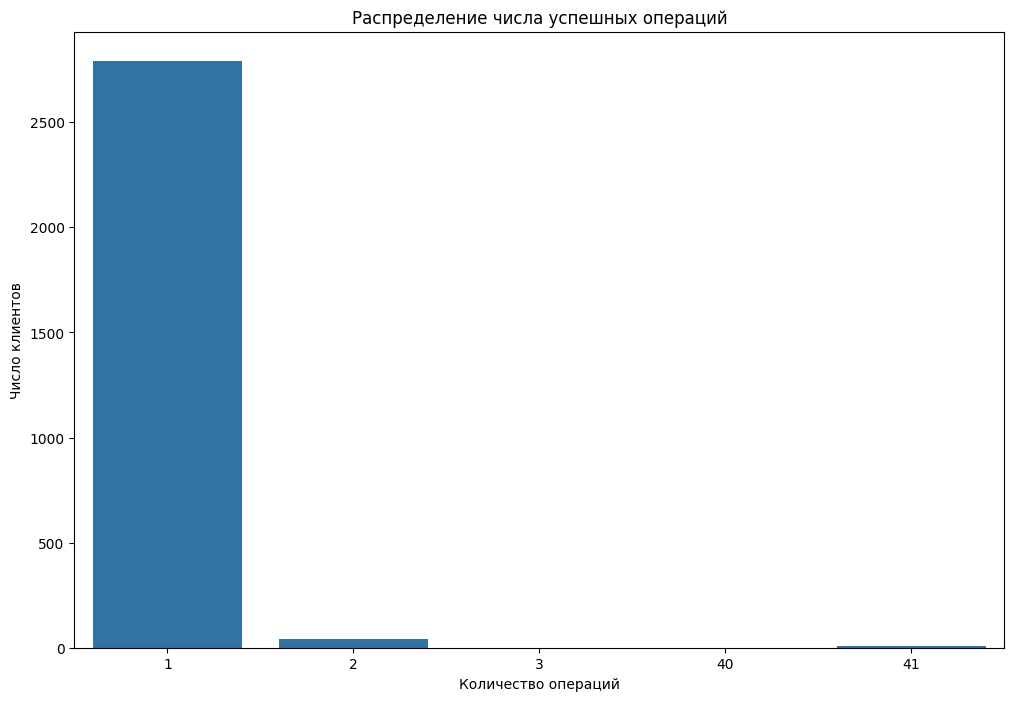

In [99]:
# Построим график распределения числа успешных операций

plt.figure(figsize=(12, 8))
counts_success_operations = (
    logs.query('success == 1')
    .groupby('client', as_index=False)
    .agg(count_operation=('platform', 'count'))
    .groupby('count_operation', as_index=False)['client'].count()
)

sns.barplot(counts_success_operations, x='count_operation', y='client')
plt.title('Распределение числа успешных операций')
plt.xlabel('Количество операций')
plt.ylabel('Число клиентов')
plt.show()

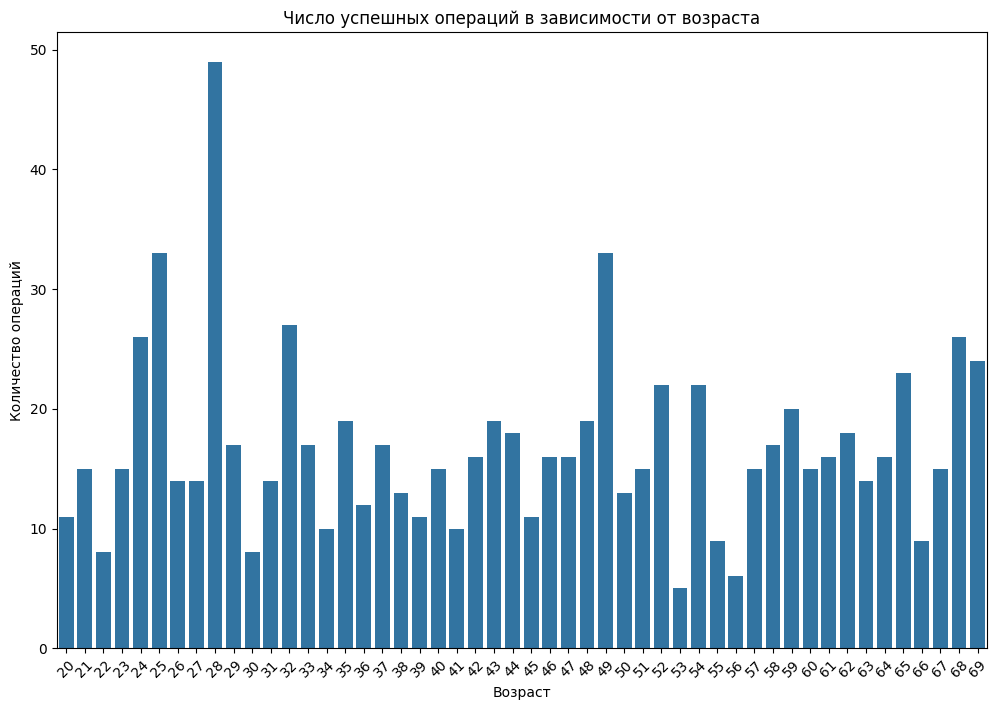

In [100]:
# Построим график распределения числа успешных операций, сделанных на платформе computer, в зависимости от возраста

counts_success_computer_operations = df.query('success == 1 and platform == "computer"')

plt.figure(figsize=(12, 8))
sns.countplot(counts_success_computer_operations, x='age')
plt.xticks(rotation=45)
plt.title('Число успешных операций в зависимости от возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество операций')
plt.show()